# PHASE 3 — ANALYSIS 3.1: Excitation Effect & Narrative Shift Trigger
## Langkah 1: Temporal Excitation Analysis
## Langkah 2: Engagement Velocity

**Version:** Updated — uses relabeled account_type files (suffix '2')

**Tujuan:**
- Langkah 1: Membuktikan bahwa setelah narrative shift (27 Agustus), struktur jaringan berubah (cross-community edges meningkat)
- Langkah 2: Mengukur kecepatan akumulasi engagement per narasi, dengan dan tanpa @barengwarga

**Input files:**
- `Data_with_community2.csv` (relabeled account_type)
- `Data_diffusion_analysis2.csv` (relabeled account_type)
- `network_edges.csv` (edge list — tidak berubah)
- `network_nodes_with_community2.csv` (relabeled account_type)

## Cell 1: Install & Import

In [1]:
!pip install networkx python-louvain -q

import pandas as pd
import numpy as np
import networkx as nx
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported.")

All libraries imported.


## Cell 2: Load & Merge Data

In [2]:
# Load base data (relabeled)
df_comm = pd.read_csv('Data_with_community2.csv')

# Load diffusion data (relabeled)
df_diff = pd.read_csv('Data_diffusion_analysis2.csv')

# Merge: ambil diffusion_score dari df_diff ke df_comm via tweet_url
df = df_comm.merge(
    df_diff[['tweet_url', 'diffusion_score']],
    on='tweet_url',
    how='left'
)

# Parse date
df['date'] = pd.to_datetime(df['date'])
df['date_day'] = df['date'].dt.date

# Shift date
shift_date = pd.Timestamp('2025-08-27')
df['phase'] = df['date'].apply(lambda x: 'Pre-shift' if x < shift_date else 'Post-shift')

# Engagement
engagement_cols = ['retweet_count', 'reply_count', 'quote_count', 'favorite_count', 'view_count']
for col in engagement_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)
df['total_engagement'] = df[engagement_cols].sum(axis=1)

# barengwarga mask
bw_mask = df['username'].str.lower().str.strip().str.replace('@', '') == 'barengwarga'
df_clean = df[~bw_mask].copy()

print(f"Merged dataset: {len(df)} rows")
print(f"Without @barengwarga: {len(df_clean)} rows")
print(f"Diffusion score available: {df['diffusion_score'].notna().sum()} ({df['diffusion_score'].notna().mean()*100:.1f}%)")
print(f"\nAccount type distribution (relabeled):")
print(df['account_type'].value_counts())
print(f"\nPhase distribution:")
print(df['phase'].value_counts())
print(f"\nNarrative distribution:")
print(df['narrative'].value_counts())

Merged dataset: 14248 rows
Without @barengwarga: 14237 rows
Diffusion score available: 8510 (59.7%)

Account type distribution (relabeled):
account_type
grassroot          13640
media/news           535
elite/political       73
Name: count, dtype: int64

Phase distribution:
phase
Post-shift    8459
Pre-shift     5789
Name: count, dtype: int64

Narrative distribution:
narrative
Demo & DPR            2482
Gerakan/Hashtag       2356
Kekerasan Aparat      2276
Politik & Tuntutan    1437
Ekonomi Rakyat        1277
Affan Kurniawan        743
Keamanan & Respons     206
Name: count, dtype: int64


## Cell 3: Load Network Data

In [3]:
# Load edges
edges = pd.read_csv('network_edges.csv')

# Load nodes with community (relabeled)
nodes = pd.read_csv('network_nodes_with_community2.csv')

print(f"Edges: {len(edges)}")
print(f"Nodes: {len(nodes)}")
print(f"\nEdge columns: {edges.columns.tolist()}")
print(f"Node columns: {nodes.columns.tolist()}")

# Buat community lookup dari nodes
community_lookup = dict(zip(nodes['username'], nodes['community']))
print(f"\nCommunity lookup size: {len(community_lookup)}")

Edges: 13994
Nodes: 11426

Edge columns: ['source', 'target', 'weight', 'dominant_type', 'dominant_topic', 'first_interaction', 'last_interaction']
Node columns: ['username', 'community', 'account_type', 'in_degree', 'out_degree']

Community lookup size: 11426


---
# LANGKAH 1: TEMPORAL EXCITATION ANALYSIS
Apakah struktur jaringan berubah setelah narrative shift?

## Cell 4: Cek Edge Columns

In [4]:
print("Edge columns:", edges.columns.tolist())
print("\nSample edges:")
print(edges.head())
print("\nEdge dtypes:")
print(edges.dtypes)

Edge columns: ['source', 'target', 'weight', 'dominant_type', 'dominant_topic', 'first_interaction', 'last_interaction']

Sample edges:
           source       target  weight dominant_type  dominant_topic  \
0    yang _tampan  joey_ardiva       1       mention               0   
1     yang gilang   tempodotco       1       mention               0   
2   yang mi3prnew       dpr_ri       2       mention               4   
3   yang mi3prnew      prabowo       2       mention               4   
4    007_atacante    ds_yantie       2         reply               2   

     first_interaction     last_interaction  
0  2025-08-28 16:50:00  2025-08-28 16:50:00  
1  2025-08-19 16:06:00  2025-08-19 16:06:00  
2  2025-08-27 07:22:00  2025-08-31 00:44:00  
3  2025-08-27 07:22:00  2025-08-31 00:44:00  
4  2025-08-22 05:56:00  2025-08-22 05:56:00  

Edge dtypes:
source               object
target               object
weight                int64
dominant_type        object
dominant_topic        int64
f

## Cell 5: Rekonstruksi Temporal Edges

In [5]:
temporal_edges = []

for _, row in df.iterrows():
    source = str(row['username_clean']).lower().strip() if pd.notna(row.get('username_clean')) else str(row['username']).lower().strip()
    source = source.replace('@', '')
    tweet_date = row['date']
    narrative = row['narrative']
    phase = row['phase']
    account_type = row['account_type']

    # Reply edges
    if pd.notna(row.get('in_reply_to_screen_name')):
        target = str(row['in_reply_to_screen_name']).lower().strip().replace('@', '')
        if source != target:
            temporal_edges.append({
                'source': source, 'target': target,
                'edge_type': 'reply', 'date': tweet_date,
                'narrative': narrative, 'phase': phase,
                'account_type': account_type
            })

    # Quote edges
    if pd.notna(row.get('quoted_username')):
        target = str(row['quoted_username']).lower().strip().replace('@', '')
        if source != target:
            temporal_edges.append({
                'source': source, 'target': target,
                'edge_type': 'quote', 'date': tweet_date,
                'narrative': narrative, 'phase': phase,
                'account_type': account_type
            })

    # Mention edges
    if pd.notna(row.get('mentions')):
        mentions_list = str(row['mentions']).replace('@', '').split()
        for m in mentions_list:
            target = m.lower().strip()
            if source != target and target != '':
                temporal_edges.append({
                    'source': source, 'target': target,
                    'edge_type': 'mention', 'date': tweet_date,
                    'narrative': narrative, 'phase': phase,
                    'account_type': account_type
                })

df_edges_temporal = pd.DataFrame(temporal_edges)
df_edges_temporal['date'] = pd.to_datetime(df_edges_temporal['date'])
df_edges_temporal['date_day'] = df_edges_temporal['date'].dt.date

# Assign community
df_edges_temporal['source_community'] = df_edges_temporal['source'].map(community_lookup)
df_edges_temporal['target_community'] = df_edges_temporal['target'].map(community_lookup)

# Flag cross-community
df_edges_temporal['is_cross_community'] = (
    df_edges_temporal['source_community'].notna() &
    df_edges_temporal['target_community'].notna() &
    (df_edges_temporal['source_community'] != df_edges_temporal['target_community'])
)

print(f"Total temporal edges: {len(df_edges_temporal)}")
print(f"Cross-community edges: {df_edges_temporal['is_cross_community'].sum()} ({df_edges_temporal['is_cross_community'].mean()*100:.1f}%)")
print(f"\nEdge type distribution:")
print(df_edges_temporal['edge_type'].value_counts())
print(f"\nPhase distribution:")
print(df_edges_temporal['phase'].value_counts())
print(f"\nAccount type of edge sources:")
print(df_edges_temporal['account_type'].value_counts())
print(f"\nCross-community edges by account type:")
cross = df_edges_temporal[df_edges_temporal['is_cross_community']]
print(cross['account_type'].value_counts())
pct = cross['account_type'].value_counts(normalize=True) * 100
print(f"\nGrassroot cross-community: {pct.get('grassroot', 0):.1f}%")

Total temporal edges: 21420
Cross-community edges: 3258 (15.2%)

Edge type distribution:
edge_type
mention    13133
reply       5473
quote       2814
Name: count, dtype: int64

Phase distribution:
phase
Post-shift    10750
Pre-shift     10670
Name: count, dtype: int64

Account type of edge sources:
account_type
grassroot          21349
elite/political       41
media/news            30
Name: count, dtype: int64

Cross-community edges by account type:
account_type
grassroot          3244
elite/political      13
media/news            1
Name: count, dtype: int64

Grassroot cross-community: 99.6%


## Cell 6: Pre vs Post Shift — Network Structure Comparison

In [6]:
print("=" * 70)
print("NETWORK STRUCTURE: PRE-SHIFT vs POST-SHIFT")
print("=" * 70)

for phase_name in ['Pre-shift', 'Post-shift']:
    phase_edges = df_edges_temporal[df_edges_temporal['phase'] == phase_name]
    total = len(phase_edges)
    cross_count = phase_edges['is_cross_community'].sum()
    ratio = cross_count / total * 100 if total > 0 else 0

    unique_sources = phase_edges['source'].nunique()
    unique_targets = phase_edges['target'].nunique()
    unique_communities_source = phase_edges['source_community'].dropna().nunique()
    unique_communities_target = phase_edges['target_community'].dropna().nunique()

    # Cross-community by account type
    phase_cross = phase_edges[phase_edges['is_cross_community']]

    print(f"\n--- {phase_name} ---")
    print(f"Total edges: {total}")
    print(f"Cross-community edges: {cross_count} ({ratio:.1f}%)")
    print(f"Intra-community edges: {total - cross_count} ({100 - ratio:.1f}%)")
    print(f"Unique sources: {unique_sources}")
    print(f"Unique targets: {unique_targets}")
    print(f"Active source communities: {unique_communities_source}")
    print(f"Active target communities: {unique_communities_target}")
    print(f"Cross-community by account type:")
    print(f"  {phase_cross['account_type'].value_counts().to_dict()}")
    if len(phase_cross) > 0:
        pct_gr = (phase_cross['account_type'] == 'grassroot').mean() * 100
        print(f"  Grassroot: {pct_gr:.1f}%")

# Chi-squared test
pre_edges = df_edges_temporal[df_edges_temporal['phase'] == 'Pre-shift']
post_edges = df_edges_temporal[df_edges_temporal['phase'] == 'Post-shift']

contingency = pd.DataFrame({
    'Pre-shift': [pre_edges['is_cross_community'].sum(), (~pre_edges['is_cross_community']).sum()],
    'Post-shift': [post_edges['is_cross_community'].sum(), (~post_edges['is_cross_community']).sum()]
}, index=['Cross-community', 'Intra-community'])

chi2, p_chi, dof, expected = stats.chi2_contingency(contingency)

print(f"\n{'=' * 70}")
print(f"Chi-squared test (cross-community proportion pre vs post):")
print(f"Chi2 = {chi2:.4f}, p = {p_chi:.6f}, dof = {dof}")
print(f"{'Significant' if p_chi < 0.05 else 'Not significant'} at alpha=0.05")
print(f"\nContingency table:")
print(contingency)

NETWORK STRUCTURE: PRE-SHIFT vs POST-SHIFT

--- Pre-shift ---
Total edges: 10670
Cross-community edges: 1445 (13.5%)
Intra-community edges: 9225 (86.5%)
Unique sources: 3191
Unique targets: 2736
Active source communities: 930
Active target communities: 930
Cross-community by account type:
  {'grassroot': 1440, 'elite/political': 5}
  Grassroot: 99.7%

--- Post-shift ---
Total edges: 10750
Cross-community edges: 1813 (16.9%)
Intra-community edges: 8937 (83.1%)
Unique sources: 4285
Unique targets: 2494
Active source communities: 833
Active target communities: 833
Cross-community by account type:
  {'grassroot': 1804, 'elite/political': 8, 'media/news': 1}
  Grassroot: 99.5%

Chi-squared test (cross-community proportion pre vs post):
Chi2 = 45.5781, p = 0.000000, dof = 1
Significant at alpha=0.05

Contingency table:
                 Pre-shift  Post-shift
Cross-community       1445        1813
Intra-community       9225        8937


## Cell 7: Pre vs Post Shift — Per Narrative

In [7]:
print("=" * 70)
print("CROSS-COMMUNITY EDGES: PRE vs POST SHIFT — PER NARRATIVE")
print("=" * 70)

narratives = df_edges_temporal['narrative'].dropna().unique()
results = []

for narr in sorted(narratives):
    narr_edges = df_edges_temporal[df_edges_temporal['narrative'] == narr]

    for phase_name in ['Pre-shift', 'Post-shift']:
        phase_narr = narr_edges[narr_edges['phase'] == phase_name]
        total = len(phase_narr)
        cross_count = phase_narr['is_cross_community'].sum()
        ratio = cross_count / total * 100 if total > 0 else 0
        unique_comms = phase_narr['source_community'].dropna().nunique()

        results.append({
            'narrative': narr,
            'phase': phase_name,
            'total_edges': total,
            'cross_community_edges': cross_count,
            'cross_community_ratio': round(ratio, 2),
            'active_communities': unique_comms
        })

df_results = pd.DataFrame(results)

for metric in ['total_edges', 'cross_community_edges', 'cross_community_ratio', 'active_communities']:
    pivot = df_results.pivot(index='narrative', columns='phase', values=metric)
    if 'Pre-shift' in pivot.columns and 'Post-shift' in pivot.columns:
        pivot['change'] = pivot['Post-shift'] - pivot['Pre-shift']
    print(f"\n--- {metric} ---")
    print(pivot.to_string())

CROSS-COMMUNITY EDGES: PRE vs POST SHIFT — PER NARRATIVE

--- total_edges ---
phase               Post-shift  Pre-shift  change
narrative                                        
Affan Kurniawan            568         26     542
Demo & DPR                 806       2322   -1516
Ekonomi Rakyat            1077        596     481
Gerakan/Hashtag           1724       2970   -1246
Keamanan & Respons         117         88      29
Kekerasan Aparat          2105        959    1146
Politik & Tuntutan        1398       1047     351

--- cross_community_edges ---
phase               Post-shift  Pre-shift  change
narrative                                        
Affan Kurniawan             62          8      54
Demo & DPR                  61        107     -46
Ekonomi Rakyat             143         73      70
Gerakan/Hashtag            401        584    -183
Keamanan & Respons          30         12      18
Kekerasan Aparat           273         51     222
Politik & Tuntutan         289        213

## Cell 8: Network Graph Metrics per Phase

In [8]:
print("=" * 70)
print("NETWORK GRAPH METRICS: PRE-SHIFT vs POST-SHIFT")
print("=" * 70)

for phase_name in ['Pre-shift', 'Post-shift']:
    phase_edges = df_edges_temporal[df_edges_temporal['phase'] == phase_name]

    G = nx.DiGraph()
    for _, row in phase_edges.iterrows():
        if G.has_edge(row['source'], row['target']):
            G[row['source']][row['target']]['weight'] += 1
        else:
            G.add_edge(row['source'], row['target'], weight=1)

    n_nodes = G.number_of_nodes()
    n_edges = G.number_of_edges()
    density = nx.density(G)

    in_degrees = [d for _, d in G.in_degree()]
    out_degrees = [d for _, d in G.out_degree()]

    G_undirected = G.to_undirected()
    components = list(nx.connected_components(G_undirected))
    largest_cc = max(components, key=len)

    print(f"\n--- {phase_name} ---")
    print(f"Nodes: {n_nodes}")
    print(f"Edges: {n_edges}")
    print(f"Density: {density:.6f}")
    print(f"Avg in-degree: {np.mean(in_degrees):.2f}")
    print(f"Avg out-degree: {np.mean(out_degrees):.2f}")
    print(f"Max in-degree: {max(in_degrees)}")
    print(f"Max out-degree: {max(out_degrees)}")
    print(f"Connected components: {len(components)}")
    print(f"Largest component size: {len(largest_cc)} ({len(largest_cc)/n_nodes*100:.1f}%)")

    G_lcc = G_undirected.subgraph(largest_cc)
    if len(largest_cc) <= 5000:
        avg_path = nx.average_shortest_path_length(G_lcc)
        diameter = nx.diameter(G_lcc)
        print(f"Avg shortest path (LCC): {avg_path:.2f}")
        print(f"Diameter (LCC): {diameter}")
    else:
        sample_nodes = list(largest_cc)[:500]
        paths = []
        for i, src in enumerate(sample_nodes[:100]):
            for tgt in sample_nodes[100:200]:
                try:
                    p = nx.shortest_path_length(G_lcc, src, tgt)
                    paths.append(p)
                except nx.NetworkXNoPath:
                    pass
        if paths:
            print(f"Avg shortest path (sampled, LCC): {np.mean(paths):.2f}")
            print(f"Max path (sampled): {max(paths)}")

NETWORK GRAPH METRICS: PRE-SHIFT vs POST-SHIFT

--- Pre-shift ---
Nodes: 5697
Edges: 6671
Density: 0.000206
Avg in-degree: 1.17
Avg out-degree: 1.17
Max in-degree: 181
Max out-degree: 78
Connected components: 972
Largest component size: 2963 (52.0%)
Avg shortest path (LCC): 5.12
Diameter (LCC): 15

--- Post-shift ---
Nodes: 6586
Edges: 7500
Density: 0.000173
Avg in-degree: 1.14
Avg out-degree: 1.14
Max in-degree: 506
Max out-degree: 78
Connected components: 870
Largest component size: 4412 (67.0%)
Avg shortest path (LCC): 4.97
Diameter (LCC): 17


## Cell 9: Visualisasi — Cross-Community Edges Over Time

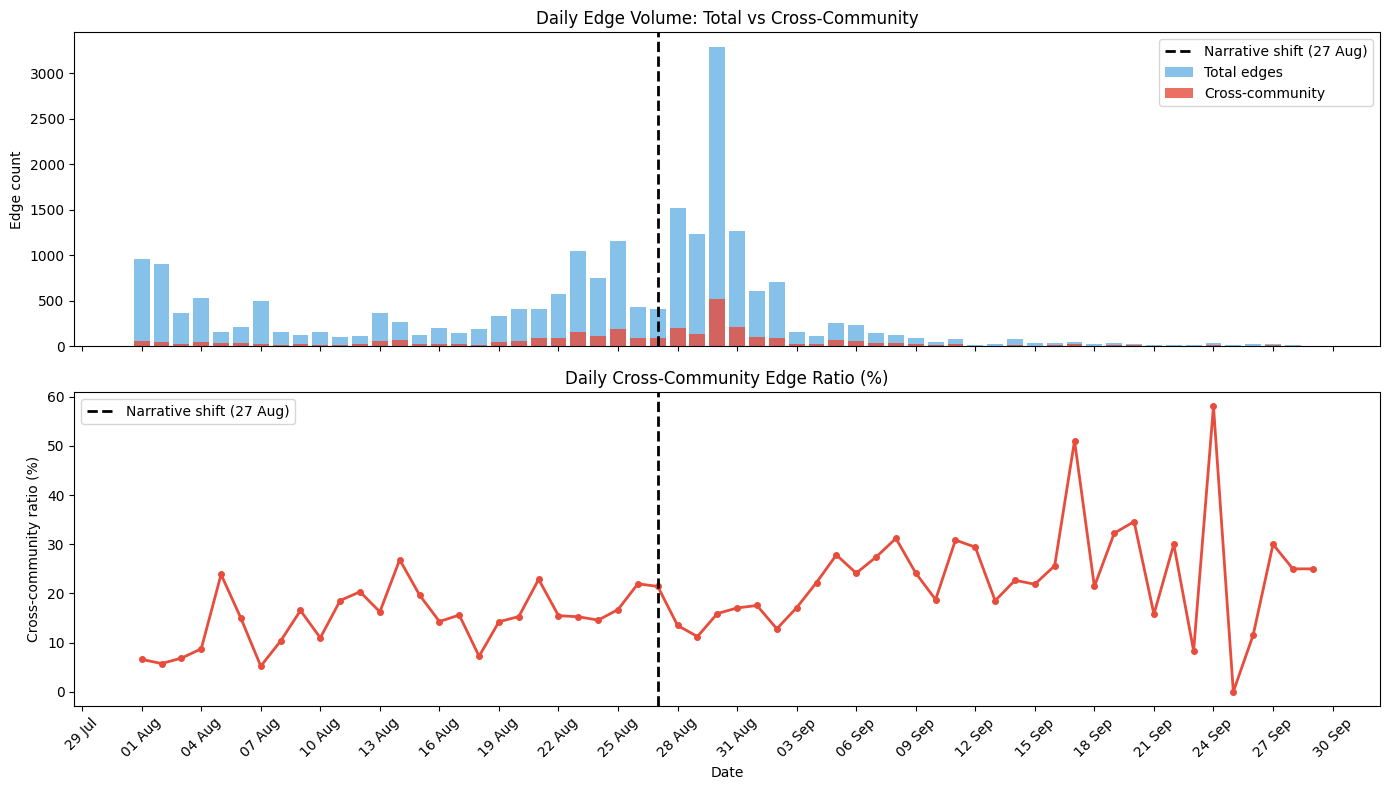


Pre-shift avg daily cross-community ratio: 14.8%
Post-shift avg daily cross-community ratio: 23.4%


In [9]:
daily_edges = df_edges_temporal.groupby('date_day').agg(
    total_edges=('is_cross_community', 'size'),
    cross_community=('is_cross_community', 'sum')
).reset_index()
daily_edges['cross_ratio'] = daily_edges['cross_community'] / daily_edges['total_edges'] * 100
daily_edges['date_day'] = pd.to_datetime(daily_edges['date_day'])

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].bar(daily_edges['date_day'], daily_edges['total_edges'], color='#3498db', alpha=0.6, label='Total edges')
axes[0].bar(daily_edges['date_day'], daily_edges['cross_community'], color='#e74c3c', alpha=0.8, label='Cross-community')
axes[0].axvline(x=shift_date, color='black', linestyle='--', linewidth=2, label='Narrative shift (27 Aug)')
axes[0].set_ylabel('Edge count')
axes[0].set_title('Daily Edge Volume: Total vs Cross-Community')
axes[0].legend()

axes[1].plot(daily_edges['date_day'], daily_edges['cross_ratio'], color='#e74c3c', linewidth=2, marker='o', markersize=4)
axes[1].axvline(x=shift_date, color='black', linestyle='--', linewidth=2, label='Narrative shift (27 Aug)')
axes[1].set_ylabel('Cross-community ratio (%)')
axes[1].set_xlabel('Date')
axes[1].set_title('Daily Cross-Community Edge Ratio (%)')
axes[1].legend()

axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
axes[1].xaxis.set_major_locator(mdates.DayLocator(interval=3))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

pre_daily = daily_edges[daily_edges['date_day'] < shift_date]
post_daily = daily_edges[daily_edges['date_day'] >= shift_date]

print(f"\nPre-shift avg daily cross-community ratio: {pre_daily['cross_ratio'].mean():.1f}%")
print(f"Post-shift avg daily cross-community ratio: {post_daily['cross_ratio'].mean():.1f}%")

---
# LANGKAH 2: ENGAGEMENT VELOCITY

Semua velocity dihitung DENGAN dan TANPA @barengwarga.

## Cell 10: Engagement Velocity per Narrative (tanpa @barengwarga)

In [10]:
df_clean['hour'] = df_clean['date'].dt.floor('h')

print("=" * 70)
print("ENGAGEMENT VELOCITY: PRE-SHIFT vs POST-SHIFT (tanpa @barengwarga)")
print("=" * 70)

key_narratives = ['Demo & DPR', 'Affan Kurniawan', 'Kekerasan Aparat', 'Politik & Tuntutan', 'Ekonomi Rakyat']

velocity_results = []

for narr in key_narratives:
    for phase_name in ['Pre-shift', 'Post-shift']:
        subset = df_clean[(df_clean['narrative'] == narr) & (df_clean['phase'] == phase_name)]

        if len(subset) == 0:
            continue

        n_days = subset['date_day'].nunique()
        n_hours = subset['hour'].nunique()

        total_eng = subset['total_engagement'].sum()
        total_retweet = subset['retweet_count'].sum()

        eng_per_day = total_eng / n_days if n_days > 0 else 0
        eng_per_hour = total_eng / n_hours if n_hours > 0 else 0
        retweet_per_day = total_retweet / n_days if n_days > 0 else 0
        tweets_per_day = len(subset) / n_days if n_days > 0 else 0

        velocity_results.append({
            'narrative': narr,
            'phase': phase_name,
            'n_tweets': len(subset),
            'n_days': n_days,
            'n_hours_active': n_hours,
            'total_engagement': int(total_eng),
            'tweets_per_day': round(tweets_per_day, 1),
            'engagement_per_day': round(eng_per_day, 1),
            'engagement_per_hour': round(eng_per_hour, 1),
            'retweet_per_day': round(retweet_per_day, 1),
            'mean_engagement_per_tweet': round(subset['total_engagement'].mean(), 1),
            'median_engagement_per_tweet': round(subset['total_engagement'].median(), 1)
        })

df_velocity = pd.DataFrame(velocity_results)
print(df_velocity.to_string(index=False))

ENGAGEMENT VELOCITY: PRE-SHIFT vs POST-SHIFT (tanpa @barengwarga)
         narrative      phase  n_tweets  n_days  n_hours_active  total_engagement  tweets_per_day  engagement_per_day  engagement_per_hour  retweet_per_day  mean_engagement_per_tweet  median_engagement_per_tweet
        Demo & DPR  Pre-shift      1541      26             304           2172367            59.3             83552.6               7145.9            152.1                     1409.7                         74.0
        Demo & DPR Post-shift       939      19             143            719791            49.4             37883.7               5033.5            178.7                      766.6                          0.0
   Affan Kurniawan  Pre-shift        14      10              13              9195             1.4               919.5                707.3              4.1                      656.8                         38.0
   Affan Kurniawan Post-shift       729      14             172           4950540     

## Cell 11: Daily Engagement Trajectory

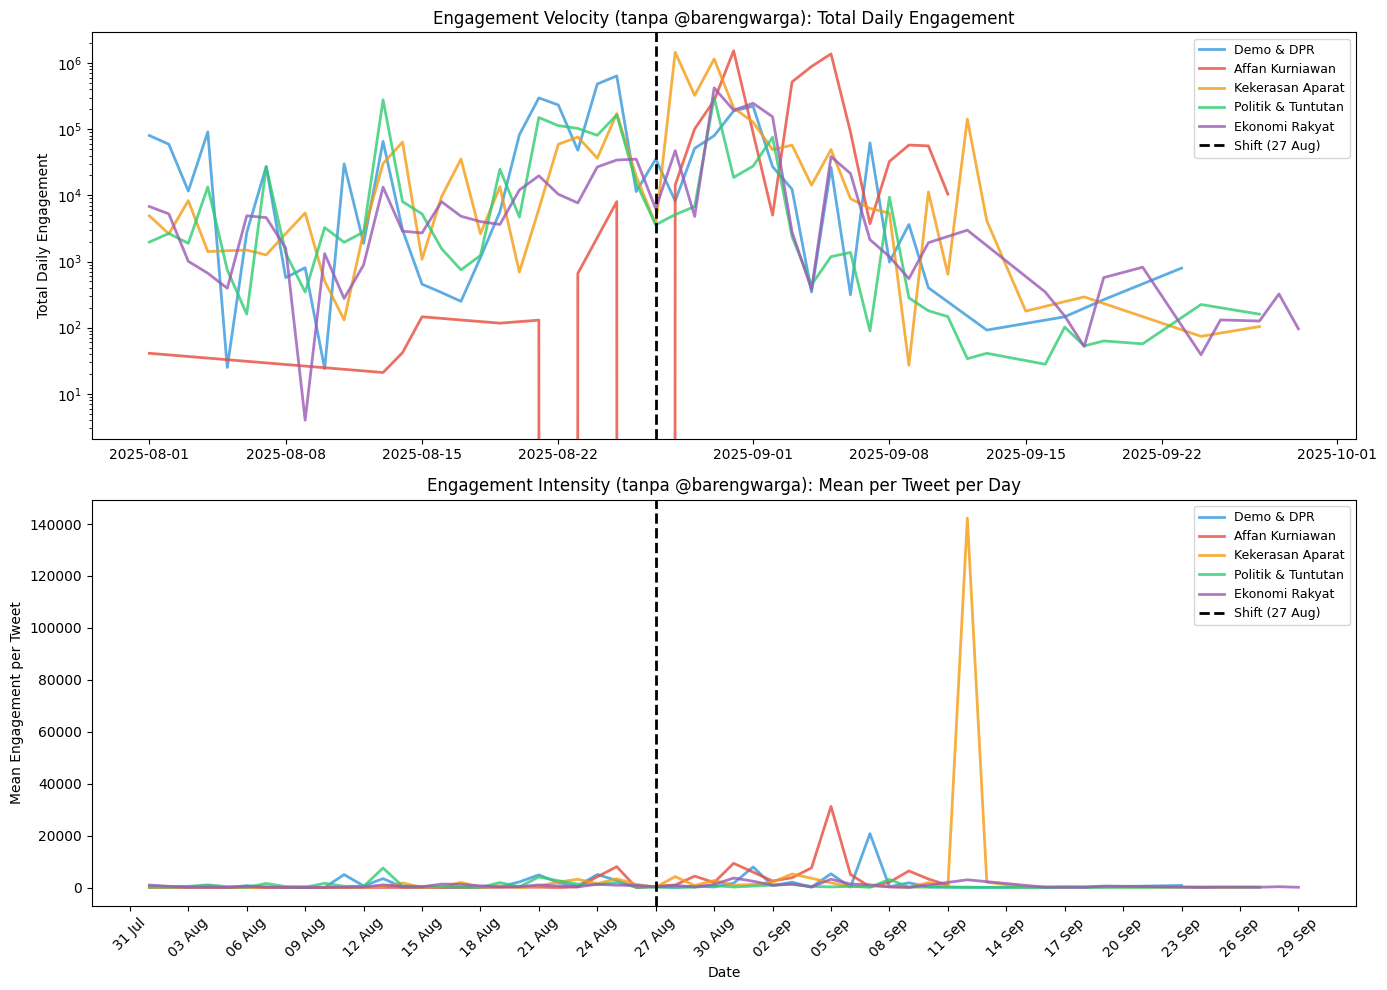

In [11]:
daily_engagement = df_clean.groupby(['date_day', 'narrative']).agg(
    n_tweets=('total_engagement', 'size'),
    total_engagement=('total_engagement', 'sum'),
    mean_engagement=('total_engagement', 'mean'),
    total_retweet=('retweet_count', 'sum'),
    total_view=('view_count', 'sum')
).reset_index()
daily_engagement['date_day'] = pd.to_datetime(daily_engagement['date_day'])

colors = {
    'Demo & DPR': '#3498db',
    'Affan Kurniawan': '#e74c3c',
    'Kekerasan Aparat': '#f39c12',
    'Politik & Tuntutan': '#2ecc71',
    'Ekonomi Rakyat': '#9b59b6'
}

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

for narr in key_narratives:
    subset = daily_engagement[daily_engagement['narrative'] == narr]
    if len(subset) > 0:
        axes[0].plot(subset['date_day'], subset['total_engagement'],
                    label=narr, color=colors.get(narr, 'gray'), linewidth=2, alpha=0.8)

axes[0].axvline(x=shift_date, color='black', linestyle='--', linewidth=2, label='Shift (27 Aug)')
axes[0].set_ylabel('Total Daily Engagement')
axes[0].set_title('Engagement Velocity (tanpa @barengwarga): Total Daily Engagement')
axes[0].legend(loc='upper right', fontsize=9)
axes[0].set_yscale('log')

for narr in key_narratives:
    subset = daily_engagement[daily_engagement['narrative'] == narr]
    if len(subset) > 0:
        axes[1].plot(subset['date_day'], subset['mean_engagement'],
                    label=narr, color=colors.get(narr, 'gray'), linewidth=2, alpha=0.8)

axes[1].axvline(x=shift_date, color='black', linestyle='--', linewidth=2, label='Shift (27 Aug)')
axes[1].set_ylabel('Mean Engagement per Tweet')
axes[1].set_xlabel('Date')
axes[1].set_title('Engagement Intensity (tanpa @barengwarga): Mean per Tweet per Day')
axes[1].legend(loc='upper right', fontsize=9)

axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
axes[1].xaxis.set_major_locator(mdates.DayLocator(interval=3))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Cell 12: Peak Velocity Analysis (tanpa @barengwarga)

In [12]:
print("=" * 70)
print("PEAK VELOCITY ANALYSIS (tanpa @barengwarga)")
print("=" * 70)

for narr in key_narratives:
    subset = daily_engagement[daily_engagement['narrative'] == narr]
    if len(subset) == 0:
        continue

    peak_row = subset.loc[subset['total_engagement'].idxmax()]
    peak_date = peak_row['date_day']
    peak_engagement = peak_row['total_engagement']
    peak_tweets = peak_row['n_tweets']

    first_date = subset['date_day'].min()
    time_to_peak = (peak_date - first_date).days
    days_from_shift = (peak_date - shift_date).days

    total_eng_narrative = subset['total_engagement'].sum()
    peak_concentration = peak_engagement / total_eng_narrative * 100

    peak_window = subset[
        (subset['date_day'] >= peak_date - pd.Timedelta(days=1)) &
        (subset['date_day'] <= peak_date + pd.Timedelta(days=1))
    ]
    window_concentration = peak_window['total_engagement'].sum() / total_eng_narrative * 100

    print(f"\n--- {narr} ---")
    print(f"First appearance: {first_date.strftime('%d %b %Y')}")
    print(f"Peak day: {peak_date.strftime('%d %b %Y')} ({int(peak_tweets)} tweets, {int(peak_engagement):,} engagement)")
    print(f"Time to peak: {time_to_peak} days")
    print(f"Peak relative to shift: {days_from_shift:+d} days")
    print(f"Peak day concentration: {peak_concentration:.1f}% of total engagement")
    print(f"3-day peak window: {window_concentration:.1f}% of total engagement")

PEAK VELOCITY ANALYSIS (tanpa @barengwarga)

--- Demo & DPR ---
First appearance: 01 Aug 2025
Peak day: 25 Aug 2025 (235 tweets, 637,807 engagement)
Time to peak: 24 days
Peak relative to shift: -2 days
Peak day concentration: 22.1% of total engagement
3-day peak window: 39.1% of total engagement

--- Affan Kurniawan ---
First appearance: 01 Aug 2025
Peak day: 31 Aug 2025 (164 tweets, 1,529,398 engagement)
Time to peak: 30 days
Peak relative to shift: +4 days
Peak day concentration: 30.8% of total engagement
3-day peak window: 36.3% of total engagement

--- Kekerasan Aparat ---
First appearance: 01 Aug 2025
Peak day: 28 Aug 2025 (345 tweets, 1,453,502 engagement)
Time to peak: 27 days
Peak relative to shift: +1 days
Peak day concentration: 34.8% of total engagement
3-day peak window: 42.6% of total engagement

--- Politik & Tuntutan ---
First appearance: 01 Aug 2025
Peak day: 30 Aug 2025 (395 tweets, 300,324 engagement)
Time to peak: 29 days
Peak relative to shift: +3 days
Peak day con

## Cell 13: Mann-Whitney Tests (tanpa @barengwarga)

In [13]:
print("=" * 70)
print("MANN-WHITNEY: ENGAGEMENT PER TWEET — PRE vs POST (tanpa @barengwarga)")
print("=" * 70)

for narr in key_narratives:
    pre = df_clean[(df_clean['narrative'] == narr) & (df_clean['phase'] == 'Pre-shift')]['total_engagement']
    post = df_clean[(df_clean['narrative'] == narr) & (df_clean['phase'] == 'Post-shift')]['total_engagement']

    if len(pre) >= 5 and len(post) >= 5:
        u_stat, u_p = stats.mannwhitneyu(pre, post, alternative='two-sided')
        r = 1 - (2 * u_stat) / (len(pre) * len(post))
        sig = '***' if u_p < 0.001 else '**' if u_p < 0.01 else '*' if u_p < 0.05 else 'ns'

        print(f"\n{narr}:")
        print(f"  Pre:  n={len(pre):>5}, mean={pre.mean():>10,.1f}, median={pre.median():>8,.1f}")
        print(f"  Post: n={len(post):>5}, mean={post.mean():>10,.1f}, median={post.median():>8,.1f}")
        print(f"  U={u_stat:.0f}, p={u_p:.6f}, r={r:.3f} {sig}")
    else:
        print(f"\n{narr}: insufficient data (pre={len(pre)}, post={len(post)})")

print(f"\n{'=' * 70}")
print("MANN-WHITNEY: DIFFUSION SCORE — PRE vs POST (tanpa @barengwarga)")
print("=" * 70)

df_clean_with_diff = df_clean[df_clean['diffusion_score'].notna()]

for narr in key_narratives:
    pre = df_clean_with_diff[(df_clean_with_diff['narrative'] == narr) & (df_clean_with_diff['phase'] == 'Pre-shift')]['diffusion_score']
    post = df_clean_with_diff[(df_clean_with_diff['narrative'] == narr) & (df_clean_with_diff['phase'] == 'Post-shift')]['diffusion_score']

    if len(pre) >= 5 and len(post) >= 5:
        u_stat, u_p = stats.mannwhitneyu(pre, post, alternative='two-sided')
        r = 1 - (2 * u_stat) / (len(pre) * len(post))
        sig = '***' if u_p < 0.001 else '**' if u_p < 0.01 else '*' if u_p < 0.05 else 'ns'

        print(f"\n{narr}:")
        print(f"  Pre:  n={len(pre):>5}, mean={pre.mean():>8.4f}, median={pre.median():>8.4f}")
        print(f"  Post: n={len(post):>5}, mean={post.mean():>8.4f}, median={post.median():>8.4f}")
        print(f"  U={u_stat:.0f}, p={u_p:.6f}, r={r:.3f} {sig}")
    else:
        print(f"\n{narr}: insufficient data (pre={len(pre)}, post={len(post)})")

MANN-WHITNEY: ENGAGEMENT PER TWEET — PRE vs POST (tanpa @barengwarga)

Demo & DPR:
  Pre:  n= 1541, mean=   1,409.7, median=    74.0
  Post: n=  939, mean=     766.6, median=     0.0
  U=1041372, p=0.000000, r=-0.439 ***

Affan Kurniawan:
  Pre:  n=   14, mean=     656.8, median=    38.0
  Post: n=  729, mean=   6,790.9, median=   360.0
  U=2218, p=0.000288, r=0.565 ***

Kekerasan Aparat:
  Pre:  n=  573, mean=     975.6, median=    55.0
  Post: n= 1701, mean=   2,127.8, median=    68.0
  U=488734, p=0.918032, r=-0.003 ns

Politik & Tuntutan:
  Pre:  n=  623, mean=   1,617.4, median=   129.0
  Post: n=  811, mean=     559.5, median=    23.0
  U=346455, p=0.000000, r=-0.371 ***

Ekonomi Rakyat:
  Pre:  n=  426, mean=     500.6, median=    65.0
  Post: n=  851, mean=   1,348.1, median=    56.0
  U=197368, p=0.009396, r=-0.089 **

MANN-WHITNEY: DIFFUSION SCORE — PRE vs POST (tanpa @barengwarga)

Demo & DPR:
  Pre:  n= 1290, mean= -0.0243, median= -0.2239
  Post: n=  322, mean=  0.1062, me

## Cell 14: Hourly Zoom — Shift Period

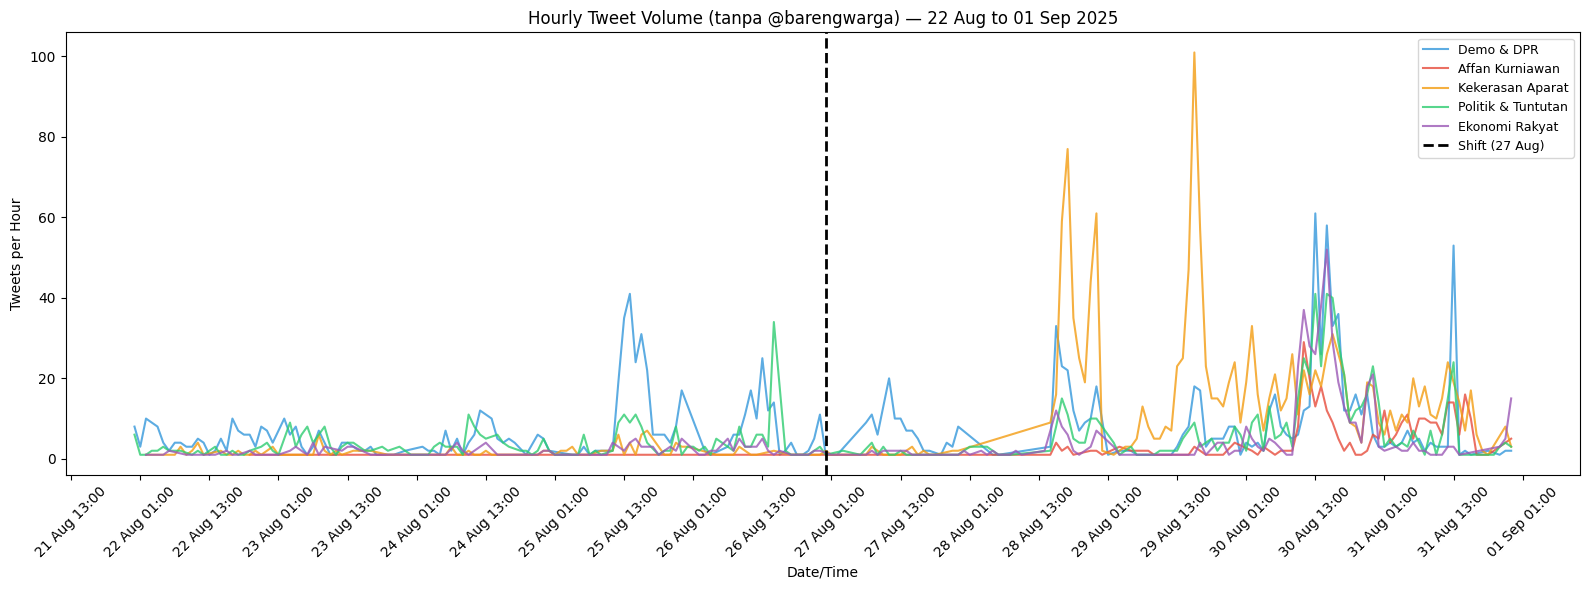


Zoom period: 22 Aug — 01 Sep 2025
Total tweets in window: 8657


In [14]:
zoom_start = shift_date - pd.Timedelta(days=5)
zoom_end = shift_date + pd.Timedelta(days=5)

df_zoom = df_clean[(df_clean['date'] >= zoom_start) & (df_clean['date'] <= zoom_end)].copy()
df_zoom['hour_bin'] = df_zoom['date'].dt.floor('h')

hourly_narr = df_zoom.groupby(['hour_bin', 'narrative']).agg(
    n_tweets=('total_engagement', 'size'),
    total_engagement=('total_engagement', 'sum')
).reset_index()

fig, ax = plt.subplots(figsize=(16, 6))

for narr in key_narratives:
    subset = hourly_narr[hourly_narr['narrative'] == narr]
    if len(subset) > 0:
        ax.plot(subset['hour_bin'], subset['n_tweets'],
                label=narr, color=colors.get(narr, 'gray'), linewidth=1.5, alpha=0.8)

ax.axvline(x=shift_date, color='black', linestyle='--', linewidth=2, label='Shift (27 Aug)')
ax.set_ylabel('Tweets per Hour')
ax.set_xlabel('Date/Time')
ax.set_title(f'Hourly Tweet Volume (tanpa @barengwarga) — {zoom_start.strftime("%d %b")} to {zoom_end.strftime("%d %b %Y")}')
ax.legend(loc='upper right', fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %H:00'))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=12))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"\nZoom period: {zoom_start.strftime('%d %b')} — {zoom_end.strftime('%d %b %Y')}")
print(f"Total tweets in window: {len(df_zoom)}")

## Cell 15: Export Results

In [15]:
df_velocity.to_csv('excitation_velocity_results2.csv', index=False)
df_edges_temporal.to_csv('temporal_edges_with_community2.csv', index=False)

from google.colab import files
files.download('excitation_velocity_results2.csv')
files.download('temporal_edges_with_community2.csv')

print("Files exported:")
print("1. excitation_velocity_results2.csv — velocity metrics per narrative per phase")
print("2. temporal_edges_with_community2.csv — all temporal edges with community and cross-community flag")
print("\nNext: Re-run Langkah 3-4 with same relabeled data.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Files exported:
1. excitation_velocity_results2.csv — velocity metrics per narrative per phase
2. temporal_edges_with_community2.csv — all temporal edges with community and cross-community flag

Next: Re-run Langkah 3-4 with same relabeled data.
